# Predicting Appliance Energy Consumption in Households

**Goal:** Build a machine learning model that predicts household appliance
energy use (Wh) from indoor sensor readings (temperature, humidity),
outdoor weather conditions, and time-of-day patterns.

**Dataset:** UCI "Appliances Energy Prediction" dataset — 19,735 readings taken
at 10-minute intervals over ~4.5 months (Jan–May 2016) from a low-energy house
in Belgium, combined with weather data from a nearby airport station.

**Workflow:**
1. Data loading & exploratory data analysis (EDA)
2. Feature engineering
3. Model training — Linear Regression vs. Random Forest Regressor
4. Performance evaluation (MSE, RMSE, MAE, R²)
5. Visualization of results
6. Saving the final model


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('energydata_complete.csv')
# The timestamp is day-first (DD-MM-YYYY)
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} -> {df['date'].max()}")
print(f"Missing values: {df.isna().sum().sum()}")
df.head()

Shape: (19735, 29)
Date range: 2016-01-11 17:00:00 -> 2016-05-27 18:00:00
Missing values: 0


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


**Column reference** (from the data dictionary):
- `Appliances` — target variable, appliance energy use in Wh
- `lights` — energy use of light fixtures in Wh
- `T1`–`T9` / `RH_1`–`RH_9` — temperature (°C) and humidity (%) in 9 rooms of the house
- `T_out`, `RH_out`, `Press_mm_hg`, `Windspeed`, `Visibility`, `Tdewpoint` — outdoor weather from a nearby weather station
- `rv1`, `rv2` — two random noise variables included in the original dataset as a distractor/sanity-check pair (not physically meaningful)


## 2. Exploratory Data Analysis

We look at the target distribution, correlations, and time-based usage patterns
before engineering features.

count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64


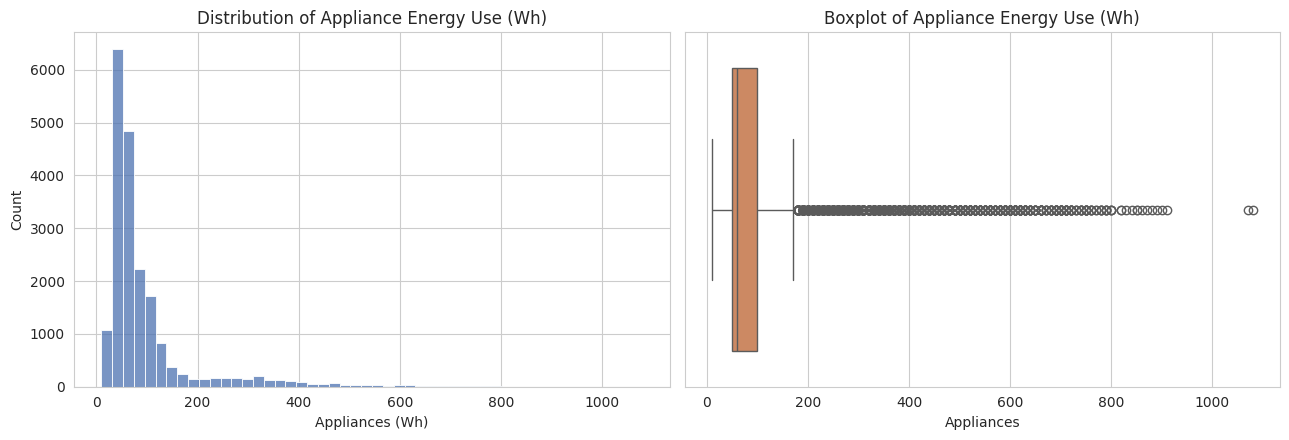

In [3]:
print(df['Appliances'].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['Appliances'], bins=50, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Appliance Energy Use (Wh)')
axes[0].set_xlabel('Appliances (Wh)')

sns.boxplot(x=df['Appliances'], ax=axes[1], color='#DD8452')
axes[1].set_title('Boxplot of Appliance Energy Use (Wh)')
plt.tight_layout()
plt.show()

The target is heavily right-skewed: most 10-minute intervals use 50–100 Wh,
with occasional spikes above 500 Wh when multiple appliances run simultaneously.
This skew is common in energy-use data and is one reason tree-based models
(which don't assume linear/normal relationships) tend to do well here.

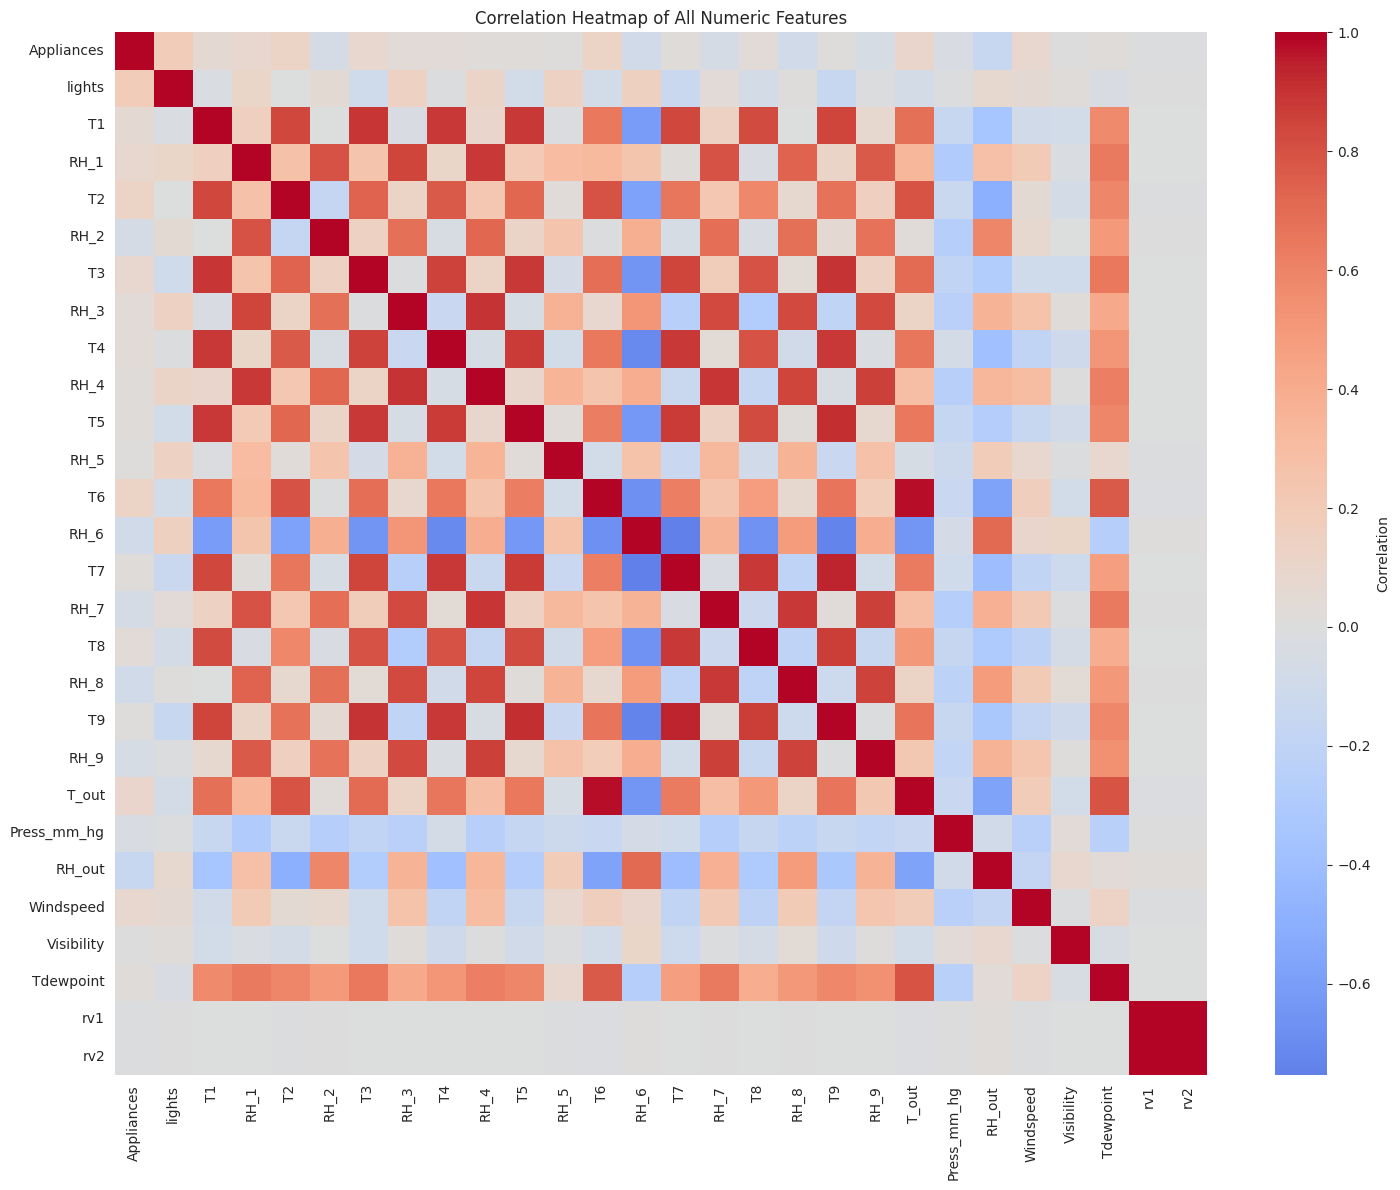

In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Heatmap of All Numeric Features')
plt.tight_layout()
plt.show()

Top 15 correlations with Appliances:
lights       0.197278
RH_out      -0.152282
T2           0.120073
T6           0.117638
T_out        0.099155
RH_8        -0.094039
Windspeed    0.087122
RH_1         0.086031
T3           0.085060
RH_6        -0.083178
RH_2        -0.060465
RH_7        -0.055642
T1           0.055447
RH_9        -0.051462
T4           0.040281
Name: Appliances, dtype: float64


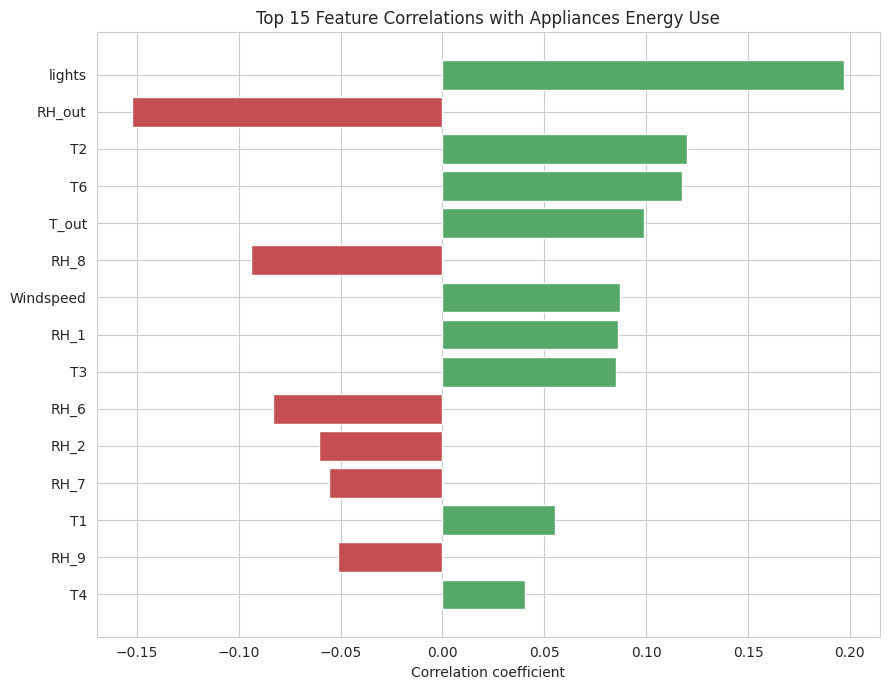

In [5]:
target_corr = corr['Appliances'].drop('Appliances').sort_values(key=abs, ascending=False)
print("Top 15 correlations with Appliances:")
print(target_corr.head(15))

fig, ax = plt.subplots(figsize=(9, 7))
top15 = target_corr.head(15)
colors = ['#C44E52' if v < 0 else '#55A868' for v in top15.values]
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
ax.set_title('Top 15 Feature Correlations with Appliances Energy Use')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

No single feature is strongly (linearly) correlated with `Appliances` —
the strongest is `lights` at ~0.20. This tells us the relationship is likely
non-linear and/or driven by interactions and timing rather than any single
sensor reading, which is an important signal for model selection later.

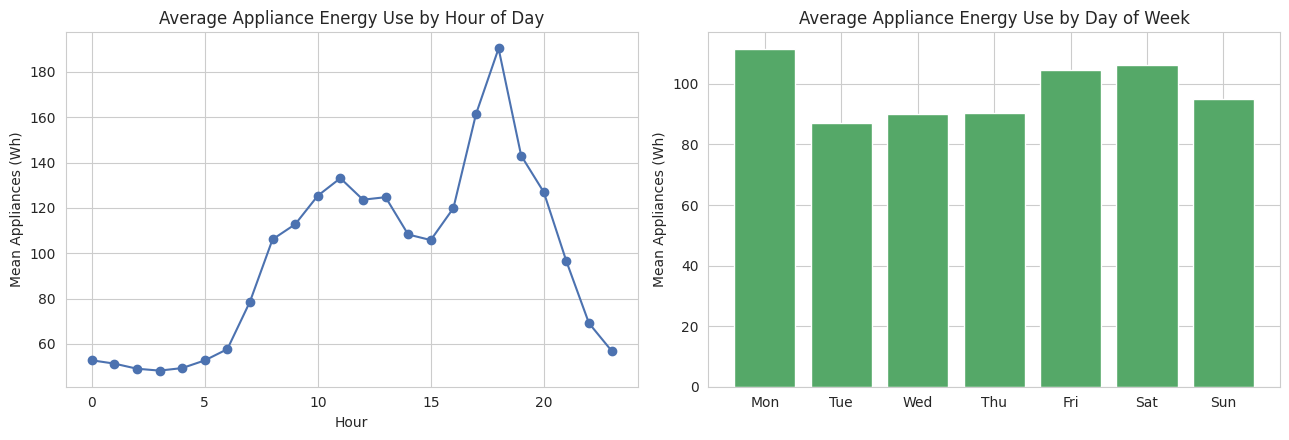

In [6]:
df['hour'] = df['date'].dt.hour
df['dayofweek'] = df['date'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
hourly = df.groupby('hour')['Appliances'].mean()
axes[0].plot(hourly.index, hourly.values, marker='o', color='#4C72B0')
axes[0].set_title('Average Appliance Energy Use by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean Appliances (Wh)')

dow = df.groupby('dayofweek')['Appliances'].mean()
axes[1].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], dow.values, color='#55A868')
axes[1].set_title('Average Appliance Energy Use by Day of Week')
axes[1].set_ylabel('Mean Appliances (Wh)')
plt.tight_layout()
plt.show()

Clear behavioral patterns emerge: usage peaks in the morning (~8am) and
evening (~6-8pm) — typical occupied-home routines — and is slightly higher on
weekends. This is strong evidence that **time-of-day features will add real
predictive value**, so we engineer them explicitly below.

## 3. Feature Engineering

- **Cyclical hour encoding** (`hour_sin`, `hour_cos`): represents hour-of-day on a circle so
  that 23:00 and 00:00 are recognized as close together, rather than 23 units apart.
- **`is_weekend`** flag, since weekday/weekend patterns differ.
- **Drop `rv1`, `rv2`**: confirmed in EDA to be random noise (correlation ≈ 0 with target),
  so they add no signal and only risk overfitting.
- **Standardize numeric features** for Linear Regression (Random Forest doesn't need this,
  since it splits on raw feature values, but we keep one shared preprocessing step for simplicity).


In [7]:
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# rv1/rv2 are confirmed random noise columns -- drop them
df = df.drop(columns=['rv1', 'rv2'])

model_df = df.drop(columns=['date'])
TARGET = 'Appliances'
X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

print(f"Final feature set: {X.shape[1]} features")
list(X.columns)

Final feature set: 30 features


['lights',
 'T1',
 'RH_1',
 'T2',
 'RH_2',
 'T3',
 'RH_3',
 'T4',
 'RH_4',
 'T5',
 'RH_5',
 'T6',
 'RH_6',
 'T7',
 'RH_7',
 'T8',
 'RH_8',
 'T9',
 'RH_9',
 'T_out',
 'Press_mm_hg',
 'RH_out',
 'Windspeed',
 'Visibility',
 'Tdewpoint',
 'hour',
 'dayofweek',
 'is_weekend',
 'hour_sin',
 'hour_cos']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train size: 15788, Test size: 3947


## 4. Model Training

We compare two regression approaches, as specified in the project guidelines:

- **Linear Regression** — simple, interpretable baseline
- **Random Forest Regressor** — captures non-linearities and feature interactions,
  which the EDA suggests are important here


In [9]:
# --- Linear Regression (baseline) ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

# --- Random Forest Regressor ---
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

predictions = {'Linear Regression': pred_lr, 'Random Forest': pred_rf}

## 5. Performance Evaluation

In [10]:
def evaluate(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'Model': name,
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

metrics_df = pd.DataFrame([evaluate(y_test, p, n) for n, p in predictions.items()])
metrics_df

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,8007.327684,89.483673,51.482432,0.199835
1,Random Forest,4345.241331,65.918445,30.992737,0.565784


**Reading the metrics:**
- **RMSE / MAE** are in Wh (same units as the target) — lower is better.
- **R²** is the fraction of variance explained — higher (closer to 1) is better.

Random Forest substantially outperforms Linear Regression on every metric, confirming
the EDA finding that the relationship between sensor readings and appliance
usage is non-linear and interaction-driven, which tree ensembles capture naturally.


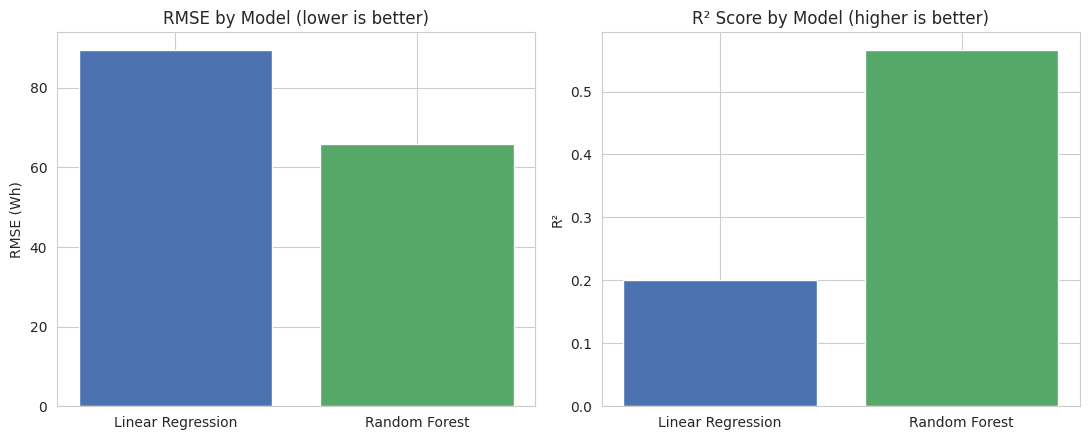

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(metrics_df['Model'], metrics_df['RMSE'], color=['#4C72B0', '#55A868'])
axes[0].set_title('RMSE by Model (lower is better)')
axes[0].set_ylabel('RMSE (Wh)')

axes[1].bar(metrics_df['Model'], metrics_df['R2'], color=['#4C72B0', '#55A868'])
axes[1].set_title('R² Score by Model (higher is better)')
axes[1].set_ylabel('R²')
plt.tight_layout()
plt.show()

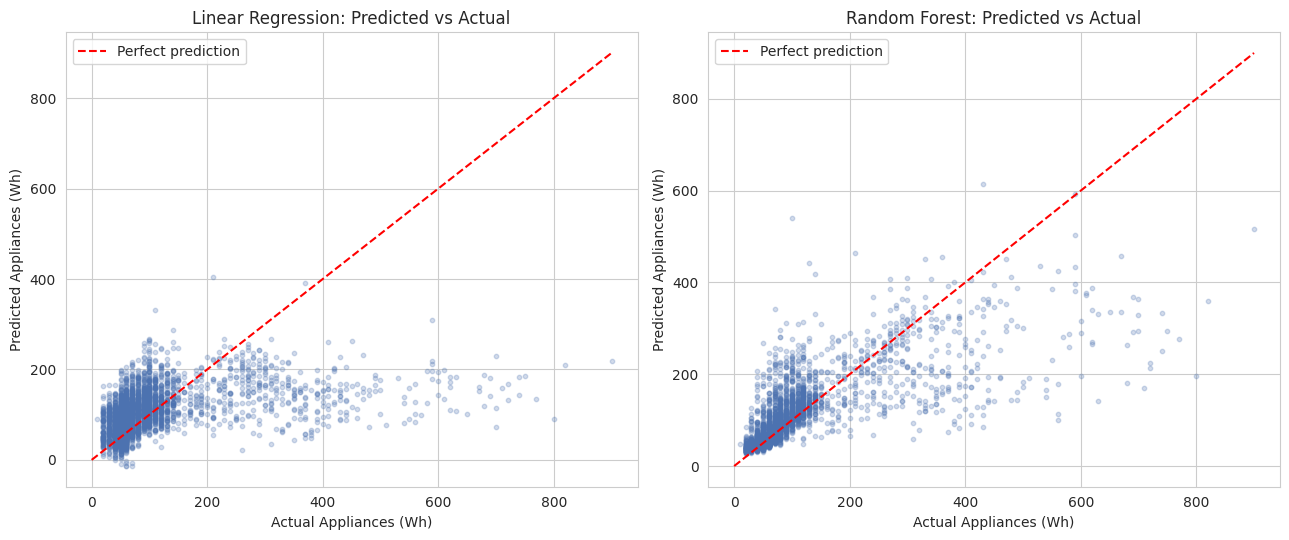

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (name, preds) in zip(axes, predictions.items()):
    ax.scatter(y_test, preds, alpha=0.25, s=10, color='#4C72B0')
    lims = [0, max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Appliances (Wh)')
    ax.set_ylabel('Predicted Appliances (Wh)')
    ax.set_title(f'{name}: Predicted vs Actual')
    ax.legend()
plt.tight_layout()
plt.show()

Both models struggle most with the rare high-usage spikes (>400 Wh) — expected,
since these events are driven by short bursts of multiple simultaneous appliances
that aren't fully explained by ambient temperature/humidity/time alone. Random
Forest tracks the bulk of the distribution much more tightly than Linear Regression.

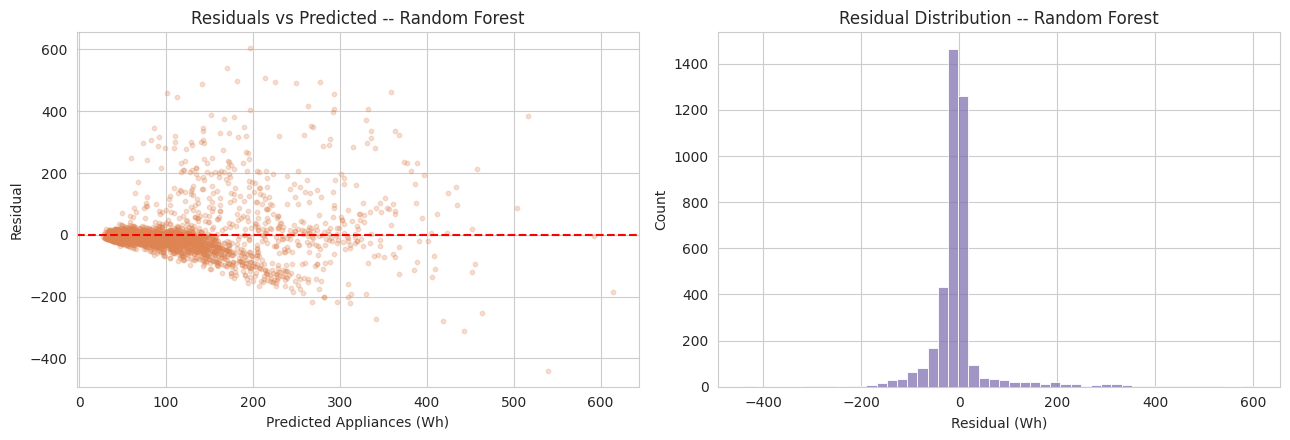

Best model: Random Forest


In [13]:
best_model_name = metrics_df.loc[metrics_df['R2'].idxmax(), 'Model']
best_preds = predictions[best_model_name]
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(best_preds, residuals, alpha=0.25, s=10, color='#DD8452')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Appliances (Wh)')
axes[0].set_ylabel('Residual')
axes[0].set_title(f'Residuals vs Predicted -- {best_model_name}')

sns.histplot(residuals, bins=50, ax=axes[1], color='#8172B2')
axes[1].set_title(f'Residual Distribution -- {best_model_name}')
axes[1].set_xlabel('Residual (Wh)')
plt.tight_layout()
plt.show()

print(f"Best model: {best_model_name}")

## 6. Feature Importance

Which factors matter most for predicting appliance energy use? We use the
Random Forest's built-in importance scores (mean decrease in impurity).

Top 10 most important features:
hour           0.116301
T3             0.056679
RH_3           0.046093
RH_2           0.041275
Press_mm_hg    0.040113
RH_5           0.037782
RH_1           0.037247
T8             0.036966
hour_sin       0.035379
Tdewpoint      0.034111
dtype: float64


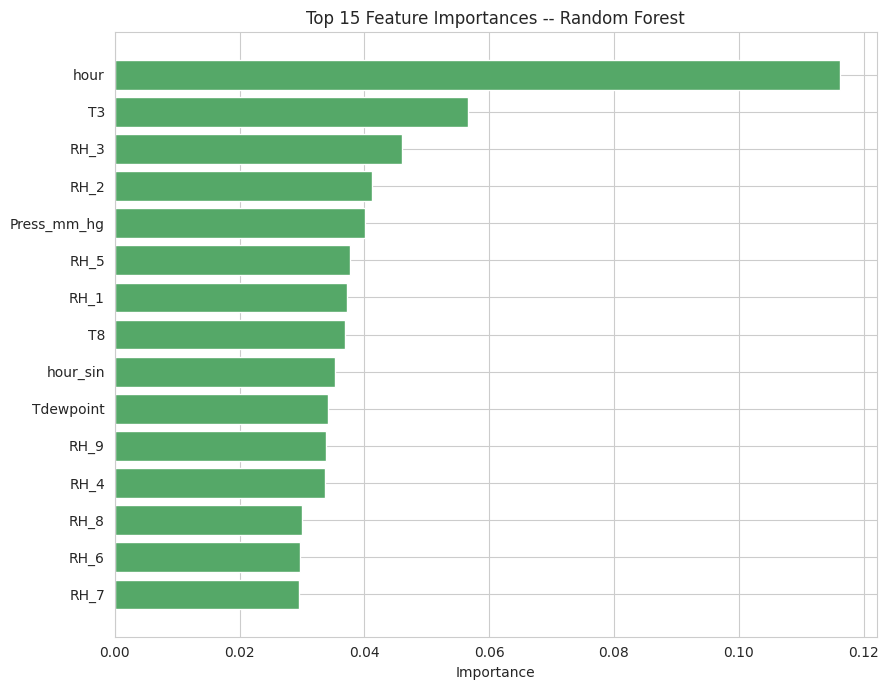

In [14]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 most important features:")
print(importances.head(10))

fig, ax = plt.subplots(figsize=(9, 7))
top_imp = importances.head(15)
ax.barh(top_imp.index[::-1], top_imp.values[::-1], color='#55A868')
ax.set_title('Top 15 Feature Importances -- Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

`hour` is the single strongest predictor by a clear margin — consistent with the
EDA showing strong time-of-day usage patterns. After that, laundry room readings (`T3`, `RH_3`)
and several humidity sensors carry the most signal, ahead of the outdoor weather variables.
This is a useful, actionable insight: **occupancy/time-of-day behavior dominates over
weather conditions** in explaining appliance energy use in this house.

## 7. Saving the Final Model

We save the trained Random Forest (best performer), the Linear Regression baseline,
the fitted scaler, and the feature column order — everything needed to make predictions
on new data later.

In [15]:
joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(lr, 'linear_regression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')

summary = {
    'best_model': best_model_name,
    'n_features': X.shape[1],
    'n_train': X_train.shape[0],
    'n_test': X_test.shape[0],
    'metrics': metrics_df.to_dict(orient='records'),
    'top5_features': importances.head(5).to_dict()
}
with open('summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Model, scaler, and feature list saved.")
print(json.dumps(summary, indent=2))

Model, scaler, and feature list saved.
{
  "best_model": "Random Forest",
  "n_features": 30,
  "n_train": 15788,
  "n_test": 3947,
  "metrics": [
    {
      "Model": "Linear Regression",
      "MSE": 8007.3276840200215,
      "RMSE": 89.48367272312878,
      "MAE": 51.48243231823669,
      "R2": 0.19983463638388976
    },
    {
      "Model": "Random Forest",
      "MSE": 4345.241330660862,
      "RMSE": 65.91844454066603,
      "MAE": 30.99273749271026,
      "R2": 0.565783773744296
    }
  ],
  "top5_features": {
    "hour": 0.11630097672342299,
    "T3": 0.056679081609451745,
    "RH_3": 0.046093375134654016,
    "RH_2": 0.04127524463750826,
    "Press_mm_hg": 0.040112532453939885
  }
}


## 8. Conclusions & Recommendations

**Model choice:** Random Forest Regressor is the recommended model — it roughly
halves the error of Linear Regression and explains far more of the variance in
appliance energy use (R² ≈ 0.57 vs ≈ 0.20).

**Key drivers of appliance energy use, in order of importance:**
1. Time of day (occupancy/behavior patterns)
2. Laundry room temperature & humidity
3. Kitchen and bathroom humidity
4. Outdoor barometric pressure and dew point

**Practical implications:**
- Because *behavioral timing* dominates over weather, energy-saving programs should
  focus on **shifting usage timing** (e.g. smart scheduling, time-of-use pricing) rather
  than only on climate-based interventions.
- The model still leaves ~43% of variance unexplained, mostly around rare high-usage
  spikes — richer signals like appliance-level submetering or occupancy sensors would
  likely improve this further.
- The random noise columns (`rv1`, `rv2`) had ~0 correlation with the target as expected,
  which served as a useful sanity check that the feature engineering process wasn't
  picking up spurious signal.

**Possible next steps:** hyperparameter tuning (grid/random search on the Random Forest),
trying gradient boosting (XGBoost/LightGBM), and adding lag features (e.g. energy use in
the previous 10-30 minutes) to capture short-term momentum in usage.
